A Logistic Regression model is developed to classify the possibility of raining the next day. The ML model is trained over Rain in Australia Dataset.

## 0. Downloading the Dataset

In [1]:
!pip install opendatasets --upgrade --quiet

In [2]:
import opendatasets as od

od.version()

'0.1.22'

In [3]:
dataset_url = "https://www.kaggle.com/jsphyg/weather-dataset-rattle-package"

od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: krasivachev
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package


100%|██████████| 3.83M/3.83M [00:00<00:00, 428MB/s]

In [4]:
import os
import pandas as pd

data_dir = "/content/weather-dataset-rattle-package"
train_csv = data_dir + "/weatherAUS.csv"

In [5]:
raw_df = pd.read_csv(train_csv)

pd.set_option("display.max_columns", None)

raw_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [7]:
raw_df.dropna(subset = ["RainToday", "RainTomorrow"], inplace = True)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140787 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           140787 non-null  object 
 1   Location       140787 non-null  object 
 2   MinTemp        140319 non-null  float64
 3   MaxTemp        140480 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81093 non-null   float64
 6   Sunshine       73982 non-null   float64
 7   WindGustDir    131624 non-null  object 
 8   WindGustSpeed  131682 non-null  float64
 9   WindDir9am     131127 non-null  object 
 10  WindDir3pm     137117 non-null  object 
 11  WindSpeed9am   139732 non-null  float64
 12  WindSpeed3pm   138256 non-null  float64
 13  Humidity9am    139270 non-null  float64
 14  Humidity3pm    137286 non-null  float64
 15  Pressure9am    127044 non-null  float64
 16  Pressure3pm    127018 non-null  float64
 17  Cloud9am       88162 non-null   fl

## 1. Analyze Dataset

In [8]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1 Plotly Plots

In [9]:
#px.histogram(raw_df, x = "Location", title = "Location vs Rainy Days", color = "RainToday")

In [10]:
#px.histogram(raw_df, x = "Temp3pm", title = "Temperature at 3 pm vs Rain Today", color = "RainToday")

In [11]:
#px.histogram(raw_df, x = "RainToday", color = "RainToday", title = "Rain Tomorrow vs Rain Today")

In [12]:
# px.scatter(raw_df.sample(2000), title = "Min Temp. vs Max Temp.", x = "MinTemp",
#            y = "MaxTemp", color = "RainToday")

### 1.2 Matplotlib Plots

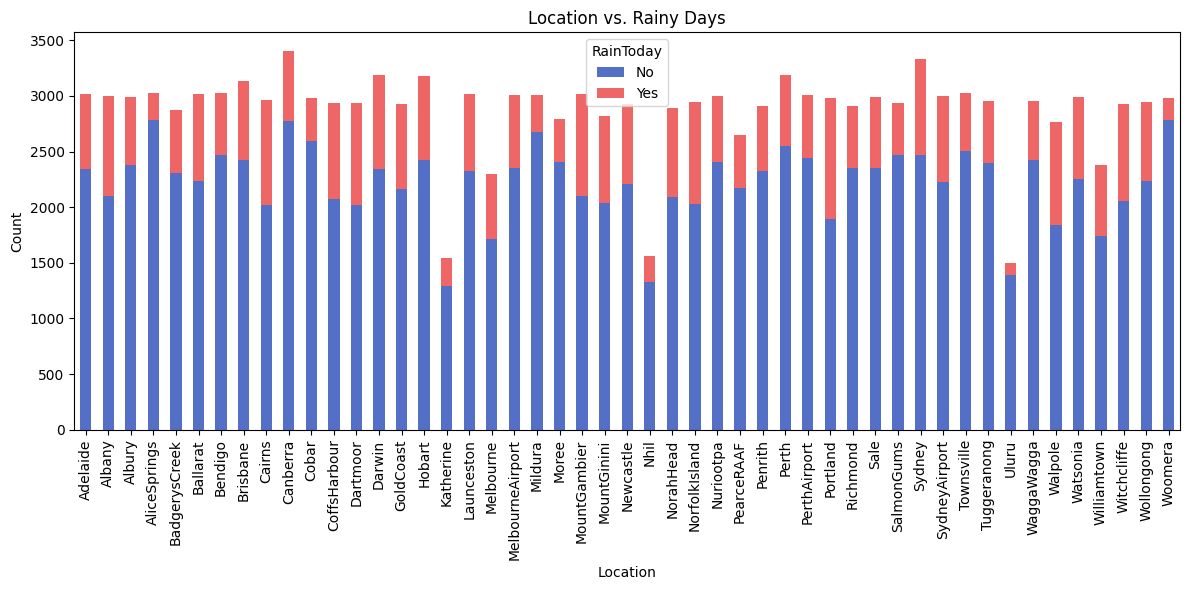

In [13]:
df_location = raw_df.pivot_table(index = "Location",
                                 columns = "RainToday",
                                 aggfunc = "size")

df_location.plot(kind = "bar", stacked = True, color=['#5470C6', '#EE6666'], figsize=(12, 6))

plt.xlabel("Location")
plt.ylabel("Count")
plt.title("Location vs. Rainy Days")
plt.legend(title = "RainToday", labels = ["No", "Yes"])
#plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

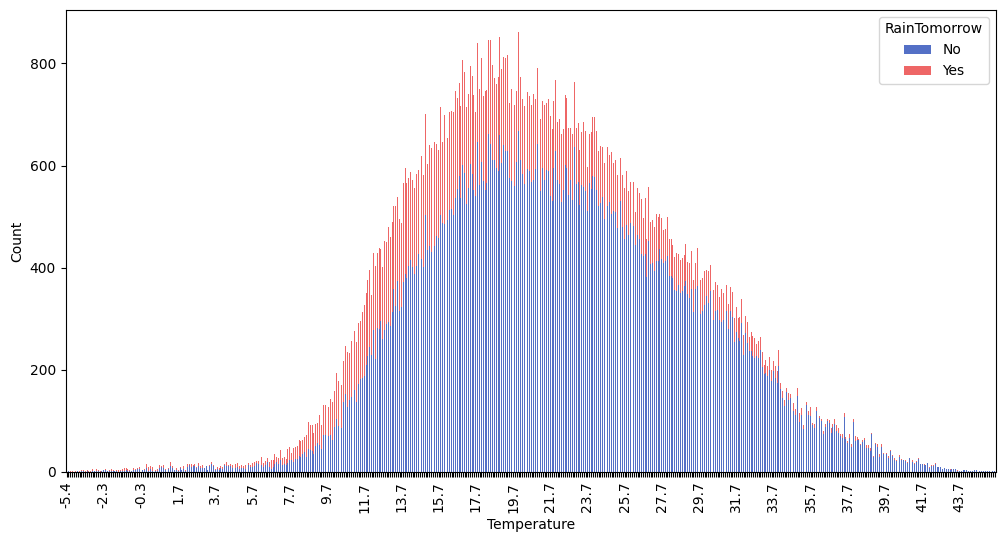

In [14]:
df_temp_3pm = raw_df.pivot_table(index = "Temp3pm",
                                 columns = "RainTomorrow",
                                 aggfunc = "size")

df_temp_3pm.plot(kind = "bar", stacked = True, color=['#5470C6', '#EE6666'],
                 xlabel = "Temperature", ylabel = "Count", figsize=(12, 6));

ax = plt.gca()
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    if i % 20 != 0:
        label.set_visible(False)

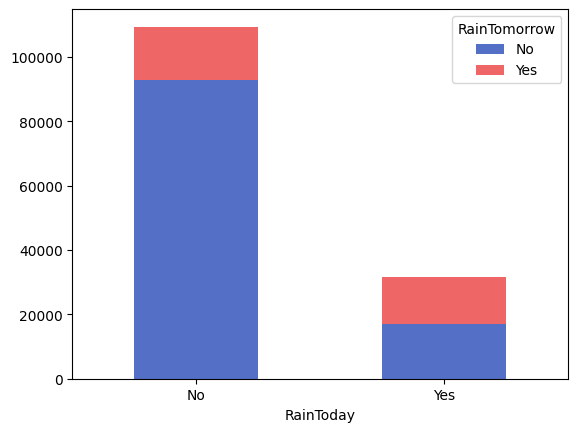

In [15]:
df_rain_relation = raw_df.pivot_table(index = "RainToday",
                                      columns = "RainTomorrow",
                                      aggfunc = "size")
df_rain_relation.plot(kind = "bar", stacked = True, color=['#5470C6', '#EE6666'], rot = 0);

## 2. Train and Test Split



### 2.1 Sklearn `train_test_split`



In [16]:
from sklearn.model_selection import train_test_split

temp_df, test_df = train_test_split(raw_df, test_size = 0.2, random_state = 42)
train_df, val_df = train_test_split(temp_df, test_size = 0.25, random_state = 42)

train_df.shape, val_df.shape, test_df.shape

((84471, 23), (28158, 23), (28158, 23))

In [17]:
year = pd.to_datetime(raw_df.Date).dt.year

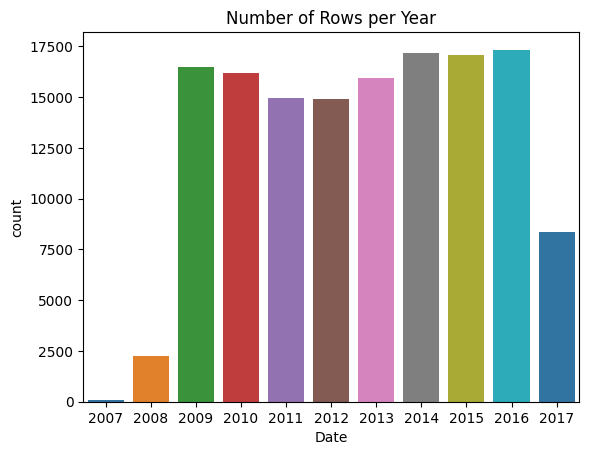

In [18]:
plt.title("Number of Rows per Year")
sns.countplot(x = year, hue = year, legend = False, palette = "tab10");

### 2.2 Year of Publishing

In [19]:
year = pd.to_datetime(raw_df.Date).dt.year

train_df = raw_df[year < 2015]
val_df = raw_df[year == 2015]
test_df = raw_df[year > 2015]

train_df.shape, val_df.shape, test_df.shape

((97988, 23), (17089, 23), (25710, 23))

## 3. Pre-processing the Data

### 3.1 Input Data and Target (Labels)

In [20]:
raw_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [21]:
input_cols = list(train_df.columns[1:-1])
target_col = "RainTomorrow"

print(input_cols)
print(target_col)

['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']
RainTomorrow


In [22]:
train_inputs = train_df[input_cols].copy()
train_target =  train_df[target_col].copy()

In [23]:
val_inputs = val_df[input_cols].copy()
val_target = val_df[target_col].copy()

In [24]:
test_inputs = test_df[input_cols].copy()
test_target = test_df[target_col].copy()

In [25]:
import numpy as np

numeric_cols = train_inputs.select_dtypes(include = np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes("object").columns.tolist()

In [26]:
numeric_cols, categorical_cols

(['MinTemp',
  'MaxTemp',
  'Rainfall',
  'Evaporation',
  'Sunshine',
  'WindGustSpeed',
  'WindSpeed9am',
  'WindSpeed3pm',
  'Humidity9am',
  'Humidity3pm',
  'Pressure9am',
  'Pressure3pm',
  'Cloud9am',
  'Cloud3pm',
  'Temp9am',
  'Temp3pm'],
 ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'])

In [27]:
train_inputs[numeric_cols].describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,97674.000000,97801.000000,97988.000000,61657.000000,57942.000000,91160.000000,97114.000000,96919.000000,96936.000000,96872.000000,88876.000000,88857.000000,63000.000000,61966.000000,97414.000000,97392.000000
mean,12.007831,23.022202,2.372935,5.289991,7.609004,40.215873,14.092263,18.764608,68.628745,51.469547,1017.513734,1015.132352,4.302952,4.410677,16.835126,21.540138
std,6.347175,6.984397,8.518819,3.952010,3.788813,13.697967,8.984203,8.872398,19.003097,20.756113,7.072510,6.997072,2.866634,2.693370,6.404586,6.831612
min,-8.500000,-4.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,979.000000,0.000000,0.000000,-5.900000,-5.100000
25%,7.500000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.800000,1010.400000,1.000000,2.000000,12.200000,16.600000
50%,11.800000,22.400000,0.000000,4.600000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.500000,1015.100000,5.000000,5.000000,16.600000,20.900000
75%,16.600000,27.900000,0.800000,7.200000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.300000,1019.900000,7.000000,7.000000,21.400000,26.200000
max,33.900000,48.100000,371.000000,82.400000,14.300000,135.000000,87.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.100000


In [28]:
train_inputs[categorical_cols].nunique()

,0
Location,49
WindGustDir,16
WindDir9am,16
WindDir3pm,16
RainToday,2


### 3.2 Impute Values

In [29]:
from sklearn.impute import SimpleImputer

In [30]:
imputer = SimpleImputer(strategy = "mean")      # Median if there are a lot of outliers

In [31]:
imputer.fit(raw_df[numeric_cols])

SimpleImputer()

In [32]:
list(imputer.statistics_)

[np.float64(12.18482386562048),
 np.float64(23.235120301822324),
 np.float64(2.349974074310839),
 np.float64(5.472515506887154),
 np.float64(7.630539861047281),
 np.float64(39.97051988882308),
 np.float64(13.990496092519967),
 np.float64(18.631140782316862),
 np.float64(68.82683277087672),
 np.float64(51.44928834695453),
 np.float64(1017.6545771543717),
 np.float64(1015.2579625879797),
 np.float64(4.431160817585808),
 np.float64(4.499250233195188),
 np.float64(16.98706638787991),
 np.float64(21.69318269001107)]

In [33]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [34]:
train_inputs[numeric_cols].isna().sum()

,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustSpeed,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0


### 3.3 Scaling

In [35]:
imputer.get_params()

{'add_indicator': False,
 'copy': True,
 'fill_value': None,
 'keep_empty_features': False,
 'missing_values': nan,
 'strategy': 'mean'}

In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(raw_df[numeric_cols])

MinMaxScaler()

In [37]:
print(f"The min values are: \n{scaler.data_min_}")
print(f"The max values are: \n{scaler.data_max_}")

The min values are: 
[ -8.5  -4.8   0.    0.    0.    6.    0.    0.    0.    0.  980.5 977.1
   0.    0.   -7.2  -5.4]
The max values are: 
[  33.9   48.1  371.   145.    14.5  135.   130.    87.   100.   100.
 1041.  1039.6    9.     9.    40.2   46.7]


In [38]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [39]:
train_inputs[numeric_cols].describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000
mean,0.483689,0.525947,0.006396,0.036949,0.525366,0.265107,0.108395,0.215668,0.686309,0.514693,0.612014,0.608705,0.483192,0.493693,0.507089,0.517103
std,0.149458,0.131904,0.022962,0.021628,0.200931,0.102420,0.068800,0.101424,0.189008,0.206376,0.111335,0.106611,0.255486,0.238028,0.134722,0.130726
min,0.000000,0.013233,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.030400,0.000000,0.000000,0.027426,0.005758
25%,0.377358,0.429112,0.000000,0.026207,0.517241,0.193798,0.053846,0.149425,0.570000,0.370000,0.543802,0.540800,0.333333,0.333333,0.409283,0.422265
50%,0.478774,0.514178,0.000000,0.037741,0.526244,0.255814,0.100000,0.218391,0.690000,0.520000,0.614125,0.610527,0.492351,0.499917,0.502110,0.506718
75%,0.591981,0.618147,0.002156,0.038621,0.634483,0.310078,0.146154,0.275862,0.830000,0.650000,0.682645,0.675200,0.666667,0.666667,0.601266,0.604607
max,1.000000,1.000000,1.000000,0.568276,0.986207,1.000000,0.669231,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.988484


### 3.4 Encoding Categorical Data

In [40]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore")
encoder.fit(raw_df[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [41]:
encoder.categories_

[array(['Adelaide', 'Albany', 'Albury', 'AliceSprings', 'BadgerysCreek',
        'Ballarat', 'Bendigo', 'Brisbane', 'Cairns', 'Canberra', 'Cobar',
        'CoffsHarbour', 'Dartmoor', 'Darwin', 'GoldCoast', 'Hobart',
        'Katherine', 'Launceston', 'Melbourne', 'MelbourneAirport',
        'Mildura', 'Moree', 'MountGambier', 'MountGinini', 'Newcastle',
        'Nhil', 'NorahHead', 'NorfolkIsland', 'Nuriootpa', 'PearceRAAF',
        'Penrith', 'Perth', 'PerthAirport', 'Portland', 'Richmond', 'Sale',
        'SalmonGums', 'Sydney', 'SydneyAirport', 'Townsville',
        'Tuggeranong', 'Uluru', 'WaggaWagga', 'Walpole', 'Watsonia',
        'Williamtown', 'Witchcliffe', 'Wollongong', 'Woomera'],
       dtype=object),
 array(['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE',
        'SSW', 'SW', 'W', 'WNW', 'WSW', nan], dtype=object),
 array(['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE',
        'SSW', 'SW', 'W', 'WNW', 'WSW', nan], dtype=object),
 ar

In [42]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)

['Location_Adelaide', 'Location_Albany', 'Location_Albury', 'Location_AliceSprings', 'Location_BadgerysCreek', 'Location_Ballarat', 'Location_Bendigo', 'Location_Brisbane', 'Location_Cairns', 'Location_Canberra', 'Location_Cobar', 'Location_CoffsHarbour', 'Location_Dartmoor', 'Location_Darwin', 'Location_GoldCoast', 'Location_Hobart', 'Location_Katherine', 'Location_Launceston', 'Location_Melbourne', 'Location_MelbourneAirport', 'Location_Mildura', 'Location_Moree', 'Location_MountGambier', 'Location_MountGinini', 'Location_Newcastle', 'Location_Nhil', 'Location_NorahHead', 'Location_NorfolkIsland', 'Location_Nuriootpa', 'Location_PearceRAAF', 'Location_Penrith', 'Location_Perth', 'Location_PerthAirport', 'Location_Portland', 'Location_Richmond', 'Location_Sale', 'Location_SalmonGums', 'Location_Sydney', 'Location_SydneyAirport', 'Location_Townsville', 'Location_Tuggeranong', 'Location_Uluru', 'Location_WaggaWagga', 'Location_Walpole', 'Location_Watsonia', 'Location_Williamtown', 'Loca

In [43]:
# train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
# val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
# test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [44]:
train_inputs = pd.concat([train_inputs[numeric_cols], pd.DataFrame(encoder.transform(train_inputs[categorical_cols]), columns=encoded_cols, index=train_inputs.index)], axis=1)
val_inputs = pd.concat([val_inputs[numeric_cols], pd.DataFrame(encoder.transform(val_inputs[categorical_cols]), columns=encoded_cols, index=val_inputs.index)], axis=1)
test_inputs = pd.concat([test_inputs[numeric_cols], pd.DataFrame(encoder.transform(test_inputs[categorical_cols]), columns=encoded_cols, index=test_inputs.index)], axis=1)

## 4. Save Data Frames

In [45]:
train_inputs.shape, train_target.shape

((97988, 118), (97988,))

In [46]:
val_inputs.shape, val_target.shape

((17089, 118), (17089,))

In [47]:
test_inputs.shape, test_target.shape

((25710, 118), (25710,))

In [48]:
import os
from pathlib import Path

save_files_dir = Path("save/")

if save_files_dir.is_dir():
    print(f"The {save_files_dir} directory exists.")
else:
    print(f"{save_files_dir} directory do not exists. Creating one...")
    save_files_dir.mkdir(parents = True, exist_ok = True)
    print(f"{save_files_dir} directory is created.")

save directory do not exists. Creating one...
save directory is created.


In [49]:
train_inputs.to_parquet("save/train_inputs.parquet")
val_inputs.to_parquet("save/val_inputs.parquet")
test_inputs.to_parquet("save/test_inputs.parquet")

In [50]:
pd.DataFrame(train_target).to_parquet("save/train_target.parquet")
pd.DataFrame(val_target).to_parquet("save/val_target.parquet")
pd.DataFrame(test_target).to_parquet("save/test_target.parquet")

In [51]:
train_inputs = pd.read_parquet('save/train_inputs.parquet')
val_inputs = pd.read_parquet('save/val_inputs.parquet')
test_inputs = pd.read_parquet('save/test_inputs.parquet')

train_target = pd.read_parquet('save/train_target.parquet')[target_col]
val_target = pd.read_parquet('save/val_target.parquet')[target_col]
test_target = pd.read_parquet('save/test_target.parquet')[target_col]

## 5. Logistic Regression Model

In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
model = LogisticRegression(solver = "liblinear")
model.fit(train_inputs[numeric_cols + encoded_cols], train_target)

LogisticRegression(solver='liblinear')

In [54]:
pd.DataFrame({
    "features": numeric_cols + encoded_cols,
    "weights": model.coef_.tolist()[0]
})

,features,weights
0,MinTemp,0.898632
1,MaxTemp,-2.879929
2,Rainfall,3.162778
3,Evaporation,0.854233
4,Sunshine,-1.671397
...,...,...
113,WindDir3pm_WNW,-0.033499
114,WindDir3pm_WSW,-0.275977
115,WindDir3pm_nan,0.074934
116,RainToday_No,-1.473521


## 6. Making Predictions and Evaluating the Model

In [55]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

In [56]:
train_preds = model.predict(X_train)

In [57]:
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [58]:
train_target

,RainTomorrow
0,No
1,No
2,No
3,No
4,No
...,...
144548,No
144549,No
144550,No
144551,No


In [59]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.94401311, 0.05598689],
       [0.94074304, 0.05925696],
       [0.96093735, 0.03906265],
       ...,
       [0.98749147, 0.01250853],
       [0.98334725, 0.01665275],
       [0.87453712, 0.12546288]])

In [60]:
model.classes_

array(['No', 'Yes'], dtype=object)

In [61]:
from sklearn.metrics import accuracy_score

accuracy_score(train_target, train_preds)

0.8519206433440829

In [62]:
from sklearn.metrics import confusion_matrix

confusion_matrix(train_target, train_preds, normalize = "true")

array([[0.94621341, 0.05378659],
       [0.4776585 , 0.5223415 ]])

In [63]:
def pred_and_plot(inputs, target, name = ""):
    preds = model.predict(inputs)

    accuracy = accuracy_score(target, preds)
    print(f"Accuracy is: {accuracy * 100:.2f}%")
    conf_matrix = confusion_matrix(target, preds, normalize = "true")

    plt.figure()
    sns.heatmap(conf_matrix, annot = True)
    plt.xlabel("Predictions")
    plt.ylabel("Target")
    plt.title(f"{name} Confusion Matrix")

    return preds

Accuracy is: 85.19%


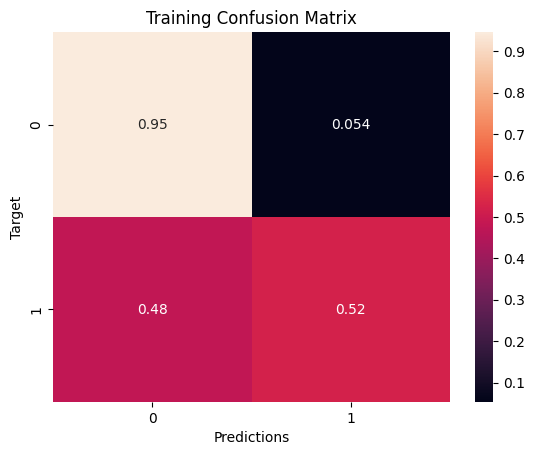

In [64]:
train_preds = pred_and_plot(X_train, train_target, "Training")

Accuracy is: 85.40%


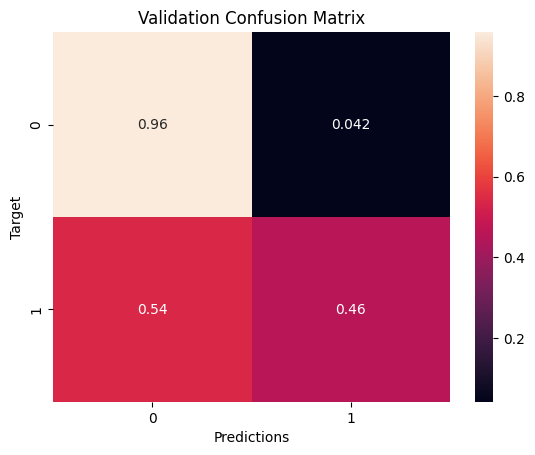

In [65]:
val_preds = pred_and_plot(X_val, val_target, "Validation")

Accuracy is: 84.20%


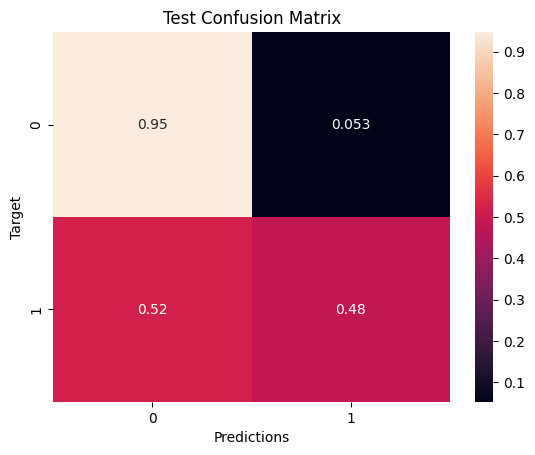

In [66]:
test_pred = pred_and_plot(X_test, test_target, "Test")

In [67]:
def random_guess(inputs):
    return np.random.choice(["No", "Yes"], len(inputs))

In [68]:
def all_no(inputs):
    return np.full(len(inputs), "No")

In [69]:
accuracy_score(test_target, random_guess(X_test))

0.5046674445740957

In [70]:
accuracy_score(test_target, all_no(X_test))

0.7734344612991054

## 7. Make Predictions on a Single Input

In [84]:
new_input = {"Date": "2022-03-04",
             "Location": "Katherine",
             "MinTemp": 20.9,
             "MaxTemp": 40.2,
             "Rainfall": 12.2,
             "Evaporation": 1.8,
             "Sunshine": np.nan,
             "WindGustDir": "NW",
             "WindGustSpeed": 49.9,
             "WindDir9am": "NW",
             "WindDir3pm": "NE",
             "WindSpeed9am": 10.4,
             "WindSpeed3pm": 18.9,
             "Humidity9am": 78.9,
             "Humidity3pm": 61.0,
             "Pressure9am": 1002.7,
             "Pressure3pm": 1001.1,
             "Cloud9am": 9.0,
             "Cloud3pm": 6.0,
             "Temp9am": 24.8,
             "Temp3pm": 34.1,
             "RainToday": "No"}

In [85]:
new_input_df = pd.DataFrame([new_input])
new_input_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,2022-03-04,Katherine,20.9,40.2,12.2,1.8,NaN,NW,49.9,NW,NE,10.4,18.9,78.9,61.0,1002.7,1001.1,9.0,6.0,24.8,34.1,No


In [96]:
new_input_df[numeric_cols] = imputer.transform(new_input_df[numeric_cols])
new_input_df[numeric_cols] = scaler.transform(new_input_df[numeric_cols])
new_input_df[encoded_cols] = encoder.transform(new_input_df[categorical_cols])

In [97]:
X_new_input = new_input_df[numeric_cols + encoded_cols]
X_new_input

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,Location_CoffsHarbour,Location_Dartmoor,Location_Darwin,Location_GoldCoast,Location_Hobart,Location_Katherine,Location_Launceston,Location_Melbourne,Location_MelbourneAirport,Location_Mildura,Location_Moree,Location_MountGambier,Location_MountGinini,Location_Newcastle,Location_Nhil,Location_NorahHead,Location_NorfolkIsland,Location_Nuriootpa,Location_PearceRAAF,Location_Penrith,Location_Perth,Location_PerthAirport,Location_Portland,Location_Richmond,Location_Sale,Location_SalmonGums,Location_Sydney,Location_SydneyAirport,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,WindGustDir_E,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindGustDir_nan,WindDir9am_E,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir9am_nan,WindDir3pm_E,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes
0,0.205586,0.092756,2.389121e-07,5.904301e-07,0.002503,-0.046852,0.000005,0.000029,0.000079,0.000061,-16.474389,-15.883639,0.012346,0.00823,0.155404,0.105916,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [98]:
prediction = model.predict(X_new_input)[0]
prediction

'Yes'

In [99]:
prob = model.predict_proba(X_new_input)[0]
prob

array([0., 1.])

In [100]:
def predict_input(single_input):
    input_df = pd.DataFrame([single_input])
    input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    pred = model.predict(X_input)[0]
    prob = model.predict_proba(X_input)[0][list(model.classes_).index(pred)]
    return pred, prob